# Modell mit LightGBM - Framework

In [ ]:
# setup

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

RANDOM_STATE = 42
N_SPLITS = 5
print("lightgbm", lgb.__version__) 

lightgbm 4.7.0


In [ ]:
# daten laden

def load_porto_seguro():
    bunch = fetch_openml(data_id=42742, as_frame=True, parser="auto")
    df = bunch.frame.copy()
    y = df.pop("target").astype(int)       
    return df, y

X_raw, y = load_porto_seguro()
print(X_raw.shape, "| positive rate:", round(float(y.mean()), 4))  

(595212, 57) | positive rate: 0.0364


In [ ]:
# gruppierung der Features

def column_groups(df):
    cols = list(df.columns)
    bin_cols  = [c for c in cols if c.endswith("_bin")]
    cat_cols  = [c for c in cols if c.endswith("_cat")]
    num_cols  = [c for c in cols if c not in bin_cols and c not in cat_cols]
    calc_cols = [c for c in cols if c.startswith("ps_calc")]   
    return {"bin": bin_cols, "cat": cat_cols, "num": num_cols, "calc": calc_cols}

groups = column_groups(X_raw)
for k, v in groups.items():
    print(f"{k:5s} {len(v)}")

bin   17
cat   14
num   26
calc  20


In [ ]:
# preprocessing 

def prepare_dtypes(df, groups):
    df = df.copy()
    for c in groups["num"] + groups["bin"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    for c in groups["cat"]:
        df[c] = df[c].astype("category")    
    return df

X = prepare_dtypes(X_raw, groups)

X["ps_missing_count"] = X.isna().sum(axis=1).astype("int32")

In [ ]:
# meta tablle 

def build_meta(df, groups):
    def grp(c):
        for g in ("ind", "reg", "car", "calc"):
            if f"ps_{g}_" in c:
                return g
        return "other"
    def typ(c):
        if c.endswith("_bin"): return "bin"
        if c.endswith("_cat"): return "cat"
        return "num"
    rows = [{
        "feature": c, "group": grp(c), "type": typ(c),
        "n_missing": int(df[c].isna().sum()),
        "pct_missing": round(float(df[c].isna().mean()) * 100, 2),
        "n_unique": int(df[c].nunique(dropna=True)),
    } for c in df.columns]
    return (pd.DataFrame(rows)
              .sort_values(["group", "type", "feature"])
              .reset_index(drop=True))

meta = build_meta(X, groups)
meta.head(12)

,feature,group,type,n_missing,pct_missing,n_unique
0,ps_calc_15_bin,calc,bin,0,0.0,2
1,ps_calc_16_bin,calc,bin,0,0.0,2
2,ps_calc_17_bin,calc,bin,0,0.0,2
3,ps_calc_18_bin,calc,bin,0,0.0,2
4,ps_calc_19_bin,calc,bin,0,0.0,2
5,ps_calc_20_bin,calc,bin,0,0.0,2
6,ps_calc_01,calc,num,0,0.0,10
7,ps_calc_02,calc,num,0,0.0,10
8,ps_calc_03,calc,num,0,0.0,10
9,ps_calc_04,calc,num,0,0.0,6


In [ ]:


def make_feature_list(groups, include_calc=True, include_missing_count=True):
    feats = groups["cat"] + groups["bin"] + groups["num"]
    if not include_calc:
        feats = [c for c in feats if not c.startswith("ps_calc")]
    if include_missing_count:
        feats = feats + ["ps_missing_count"]
    return feats

features_with_calc    = make_feature_list(groups, include_calc=True)
features_without_calc = make_feature_list(groups, include_calc=False)
print("mit calc:", len(features_with_calc), "| ohne calc:", len(features_without_calc))


mit calc: 58 | ohne calc: 38


In [ ]:
def gini_normalized(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1     # vergleichbar zur Baseline 

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

In [ ]:
# LightGBM-Classifyer und seine Parameter

def make_model(scale_pos_weight):
    return lgb.LGBMClassifier(
        n_estimators=2000,
        learning_rate=0.05,
        max_depth=4,
        num_leaves=15,               # bei LightGBM steuert man Komplexität primär hierüber
        min_child_samples=5,         # entspricht in etwa deinem min_child_weight-Gedanken
        subsample=0.8,               # Alias: bagging_fraction (braucht subsample_freq > 0)
        subsample_freq=1,            # sonst greift subsample nicht!
        colsample_bytree=0.8,        # Alias: feature_fraction
        reg_lambda=1.5,              # Alias: lambda_l2
        min_split_gain=0.0,          # das Pendant zu gamma
        objective="binary",         # nicht "binary:logistic"
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

In [ ]:
# CV-Konfiguration durchrechnen 

from sklearn.model_selection import train_test_split

def run_cv(X, y, features, spw_mode="on", verbose=True):
    Xf = X[features]                              # Indexing erhält den category-dtype
    oof = np.zeros(len(y), dtype=float)
    fold_ginis, best_iters = [], []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(Xf, y), start=1):
        X_tr, X_va = Xf.iloc[tr_idx], Xf.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        # internes Val-Set fürs Early Stopping aus dem Trainingsfold abzweigen
        X_in, X_es, y_in, y_es = train_test_split(
            X_tr, y_tr, test_size=0.2, stratify=y_tr, random_state=RANDOM_STATE
        )

        spw = ((y_in == 0).sum() / (y_in == 1).sum()) if spw_mode == "on" else 1.0

        model = make_model(spw)
        model.fit(
            X_in, y_in,
            eval_set=[(X_es, y_es)],
            eval_metric="auc",
            callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)],
        )

        proba = model.predict_proba(X_va)[:, 1]   # nutzt automatisch best_iteration
        oof[va_idx] = proba
        g = gini_normalized(y_va, proba)
        fold_ginis.append(g)
        best_iters.append(model.best_iteration_) 
        if verbose:
            print(f"  Fold {fold}: gini={g:.4f}  best_iter={model.best_iteration_}  spw={spw:.1f}")

    fold_ginis = np.array(fold_ginis)
    oof_gini = gini_normalized(y, oof)
    if verbose:
        print(f"  -> CV {fold_ginis.mean():.4f} ± {fold_ginis.std():.4f} | OOF {oof_gini:.4f}")
    return {"mean": fold_ginis.mean(), "std": fold_ginis.std(),
            "oof_gini": oof_gini, "fold_ginis": fold_ginis,
            "best_iters": best_iters, "oof": oof}

In [ ]:
# (calc x scale_pos_weight) --> 2x2-Experiment-Matrix 

experiments = {
    ("with_calc",    "spw_on"):  (features_with_calc,    "on"),
    ("with_calc",    "spw_off"): (features_with_calc,    "off"),
    ("without_calc", "spw_on"):  (features_without_calc, "on"),
    ("without_calc", "spw_off"): (features_without_calc, "off"),
}

results = {}
for (calc_tag, spw_tag), (feats, spw_mode) in experiments.items():
    print(f"\n=== {calc_tag} | {spw_tag}  ({len(feats)} features) ===")
    results[(calc_tag, spw_tag)] = run_cv(X, y, feats, spw_mode=spw_mode)


=== with_calc | spw_on  (58 features) ===


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 13884, number of negative: 367051
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027723 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1375
[LightGBM] [Info] Number of data points in the train set: 380935, number of used features: 58
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036447 -> initscore=-3.274764
[LightGBM] [Info] Start training from score -3.274764
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[1]	valid_0's auc: 0.594004	valid_0's binary_logloss: 0.164088
  Fold 1: gini=0.2089  best_iter=1  spw=26.4


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 13884, number of negative: 367051
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021503 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1383
[LightGBM] [Info] Number of data points in the train set: 380935, number of used features: 58
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036447 -> initscore=-3.274764
[LightGBM] [Info] Start training from score -3.274764
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1]	valid_0's auc: 0.594361	valid_0's binary_logloss: 0.164223
  Fold 2: gini=0.1922  best_iter=1  spw=26.4


...

[LightGBM] [Info] Number of positive: 13885, number of negative: 367051
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017034 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1188
[LightGBM] [Info] Number of data points in the train set: 380936, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036450 -> initscore=-3.274692
[LightGBM] [Info] Start training from score -3.274692
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[159]	valid_0's auc: 0.630965	valid_0's binary_logloss: 0.152671
  Fold 3: gini=0.2697  best_iter=159  spw=1.0


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 13884, number of negative: 367052
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022498 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1185
[LightGBM] [Info] Number of data points in the train set: 380936, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036447 -> initscore=-3.274766
[LightGBM] [Info] Start training from score -3.274766
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[136]	valid_0's auc: 0.62925	valid_0's binary_logloss: 0.152445
  Fold 4: gini=0.2650  best_iter=136  spw=1.0


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 13884, number of negative: 367052
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017984 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1185
[LightGBM] [Info] Number of data points in the train set: 380936, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036447 -> initscore=-3.274766
[LightGBM] [Info] Start training from score -3.274766
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[273]	valid_0's auc: 0.640356	valid_0's binary_logloss: 0.151638
  Fold 5: gini=0.2632  best_iter=273  spw=1.0
  -> CV 0.2678 ± 0.0056 | OOF 0.2676


In [ ]:
# Zusammenfassung + Vergleich zur Baseline

BASELINE_GINI = 0.26

summary = (pd.DataFrame([
        {"calc": c, "scale_pos_weight": s,
         "gini_mean": r["mean"], "gini_std": r["std"], "oof_gini": r["oof_gini"],
         "vs_baseline": r["oof_gini"] - BASELINE_GINI}
        for (c, s), r in results.items()
    ])
    .sort_values("oof_gini", ascending=False)
    .reset_index(drop=True))
summary.round(4)

,calc,scale_pos_weight,gini_mean,gini_std,oof_gini,vs_baseline
0,without_calc,spw_off,0.2678,0.0056,0.2676,0.0076
1,with_calc,spw_off,0.2663,0.0053,0.2662,0.0062
2,without_calc,spw_on,0.1937,0.0092,0.1966,-0.0634
3,with_calc,spw_on,0.1917,0.0096,0.1942,-0.0658


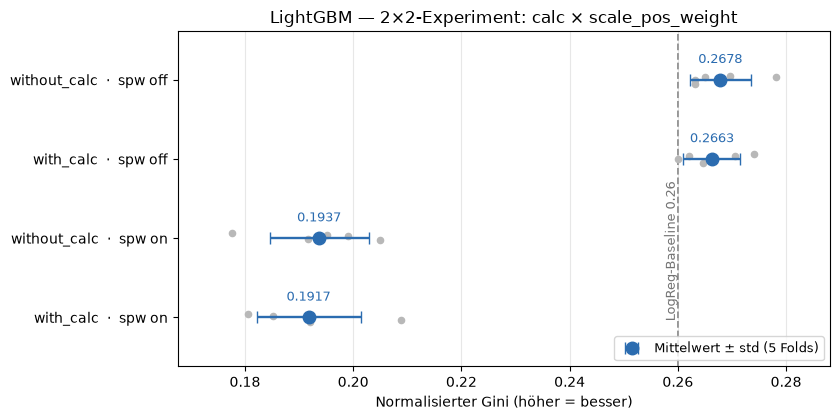

In [ ]:
# Visualisierung 

import matplotlib.pyplot as plt

rng = np.random.default_rng(RANDOM_STATE)   # reproduzierbarer Jitter

# nach OOF-Gini sortieren, beste oben
order  = sorted(results.items(), key=lambda kv: kv[1]["oof_gini"], reverse=True)
labels = [f"{c}  ·  {s.replace('spw_', 'spw ')}" for (c, s), _ in order]
means  = np.array([r["mean"] for _, r in order])
stds   = np.array([r["std"]  for _, r in order])
folds  = [r["fold_ginis"] for _, r in order]
y      = np.arange(len(order))[::-1]        # Index 0 (beste) nach oben

fig, ax = plt.subplots(figsize=(8.5, 4.3))

# Baseline
ax.axvline(BASELINE_GINI, ls="--", lw=1.3, color="0.55", zorder=1)
ax.text(BASELINE_GINI, y.min() - 0.05, f"LogReg-Baseline {BASELINE_GINI:.2f} ",
        rotation=90, va="bottom", ha="right", color="0.45", fontsize=9)

# einzelne Fold-Ginis -> zeigt die Überlappung zwischen den Konfigs
for yi, fg in zip(y, folds):
    ax.scatter(fg, np.full(len(fg), yi) + rng.uniform(-0.07, 0.07, len(fg)),
               s=20, color="0.72", zorder=2)

# Mittelwert ± std
ax.errorbar(means, y, xerr=stds, fmt="o", ms=9, color="#2b6cb0",
            capsize=4, lw=1.7, zorder=3, label="Mittelwert ± std (5 Folds)")

for yi, m in zip(y, means):
    ax.annotate(f"{m:.4f}", (m, yi), textcoords="offset points",
                xytext=(0, 12), ha="center", fontsize=9, color="#2b6cb0")

ax.set_yticks(y); ax.set_yticklabels(labels)
ax.set_xlabel("Normalisierter Gini (höher = besser)")
ax.set_title("LightGBM — 2×2-Experiment: calc × scale_pos_weight")
ax.margins(x=0.10, y=0.18)
ax.grid(axis="x", alpha=0.3)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()